In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from jaxpm import camels, data, plotting, graph
from jaxpm.painting import cic_paint, cic_read
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN

jax.devices("gpu")

[cuda(id=0)]

# functions

## training

In [3]:
@nnx.jit
def train_step(model, optimizer, x, y):

    def loss_fn(model):
        y_pred = model(*x, training=True)
        return jnp.mean((y - y_pred) **2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

@nnx.jit
def vali_loop(model, X, Y):
    losses = []
    for i in range(scales.shape[0]):
        x, y = tuple(x[i] for x in X), Y[i]
        
        losses.append(jnp.mean((y - model(*x))**2))
    losses = jnp.mean(jnp.stack(losses))

    return losses
    
# NOTE this is GD, not SGD. There's no batches, all particles in the snapshot are evaluated every step
def train_model(
    model, 
    X,
    Y,
    X_vali,
    Y_vali,
    total_steps=3_000,
    vali_every=100,
    learning_rate=1e-3,
    cosine_decay=True,
):
    optimizer = optax.chain(
        optax.clip_by_global_norm(1),
        optax.adam(learning_rate)
    )
    optimizer = nnx.Optimizer(model, optimizer)

    if cosine_decay:
        learning_rate = optax.cosine_decay_schedule(
            init_value=learning_rate, 
            decay_steps=total_steps, 
            alpha=0.1
        )

    losses = []
    vali_steps = []
    vali_losses = []
    vali_loss = np.inf
    for i in (pbar := tqdm.tqdm(range(total_steps))):
        # select single snapshot
        j = np.random.choice(np.arange(scales.shape[0]))
        x, y = tuple(x[j] for x in X), Y[j]
        
        loss = train_step(model, optimizer, x, y)
        losses.append(loss)

        if (i % vali_every == 0) and (i != 0) or i == total_steps - 1:
            vali_steps.append(i)
            vali_loss = vali_loop(model, X_vali, Y_vali)
            vali_losses.append(vali_loss)

        pbar.set_description(f"train={loss:.4f}, vali={vali_loss:.4f}")

    fig, ax = plt.subplots()
    ax.plot(losses, label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend(loc="upper right")
    ax.set(yscale="log")
    

## plotting

In [4]:
def plot_preds(pred, label, pred_vali, label_vali):
    nrows = pred_vali.shape[0]
    ncols = 2
    
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))

    # fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))
    # ncols = y_true.shape[-1]

    for i in range(nrows):
        ax[i,0].scatter(label[i], pred[i], s=0.1, color="tab:blue")
    
        ax[i,0].plot([label[i].min(), label[i].max()], [label[i].min(), label[i].max()], color="k", linestyle="--")
        ax[i,0].set_aspect("equal")
        ax[i,0].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())

    ax[0,0].set(title="training")
    
    for i in range(nrows):
        ax[i,1].scatter(label_vali[i], pred_vali[i], s=0.1, color="tab:orange")
    
        ax[i,1].plot([label_vali[i].min(), label_vali[i].max()], [label_vali[i].min(), label_vali[i].max()], color="k", linestyle="--")
        ax[i,1].set_aspect("equal")
        ax[i,1].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())
    
    ax[0,1].set(title="validation")

    fig.tight_layout()

In [5]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)


def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
    
    residual = true_field_log_sum - pred_field_log_sum
    lim = np.max(np.abs(residual[np.isfinite(residual)]))
    # print(lim)
    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

In [6]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## CAMELS snapshots

In [7]:
# i_snapshots = [-2, -1]
# i_snapshots = [0, -1]
i_snapshots = range(1, 33+4, 4)
# i_snapshots = range(1, 33+8, 8)
# i_snapshots = None
# i_snapshots = np.arange(-4, 0, dtype=int)

# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV"

# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV"


In [8]:
train_dict = camels.load_CV_snapshots(
    os.path.join(SIM, "CV_0"),
    # os.path.join(SIM, "CV_1"),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

No matching catalogs found, returning only the snapshots
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  11%|█         | 1/9 [00:01<00:10,  1.32s/it]

Found 6 duplicate gas particle IDs


finding unique gas particle indices:  22%|██▏       | 2/9 [00:07<00:27,  3.95s/it]

Found 368 duplicate gas particle IDs


...

finding unique gas particle indices:  89%|████████▉ | 8/9 [00:40<00:05,  5.47s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 9/9 [00:46<00:00,  5.14s/it]


There are 15915287 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 9/9 [01:46<00:00, 11.83s/it]


In [9]:
test_dict = camels.load_CV_snapshots(
    os.path.join(SIM, "CV_1"),
    # os.path.join(SIM, "CV_0"),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

No matching catalogs found, returning only the snapshots
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  22%|██▏       | 2/9 [00:05<00:22,  3.26s/it]

Found 66 duplicate gas particle IDs


finding unique gas particle indices:  33%|███▎      | 3/9 [00:11<00:25,  4.33s/it]

Found 279 duplicate gas particle IDs


...

finding unique gas particle indices:  89%|████████▉ | 8/9 [00:40<00:05,  5.66s/it]

Found 14533 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 9/9 [00:46<00:00,  5.16s/it]


There are 15868219 (94.58%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 9/9 [01:54<00:00, 12.71s/it]


# Preprocessing

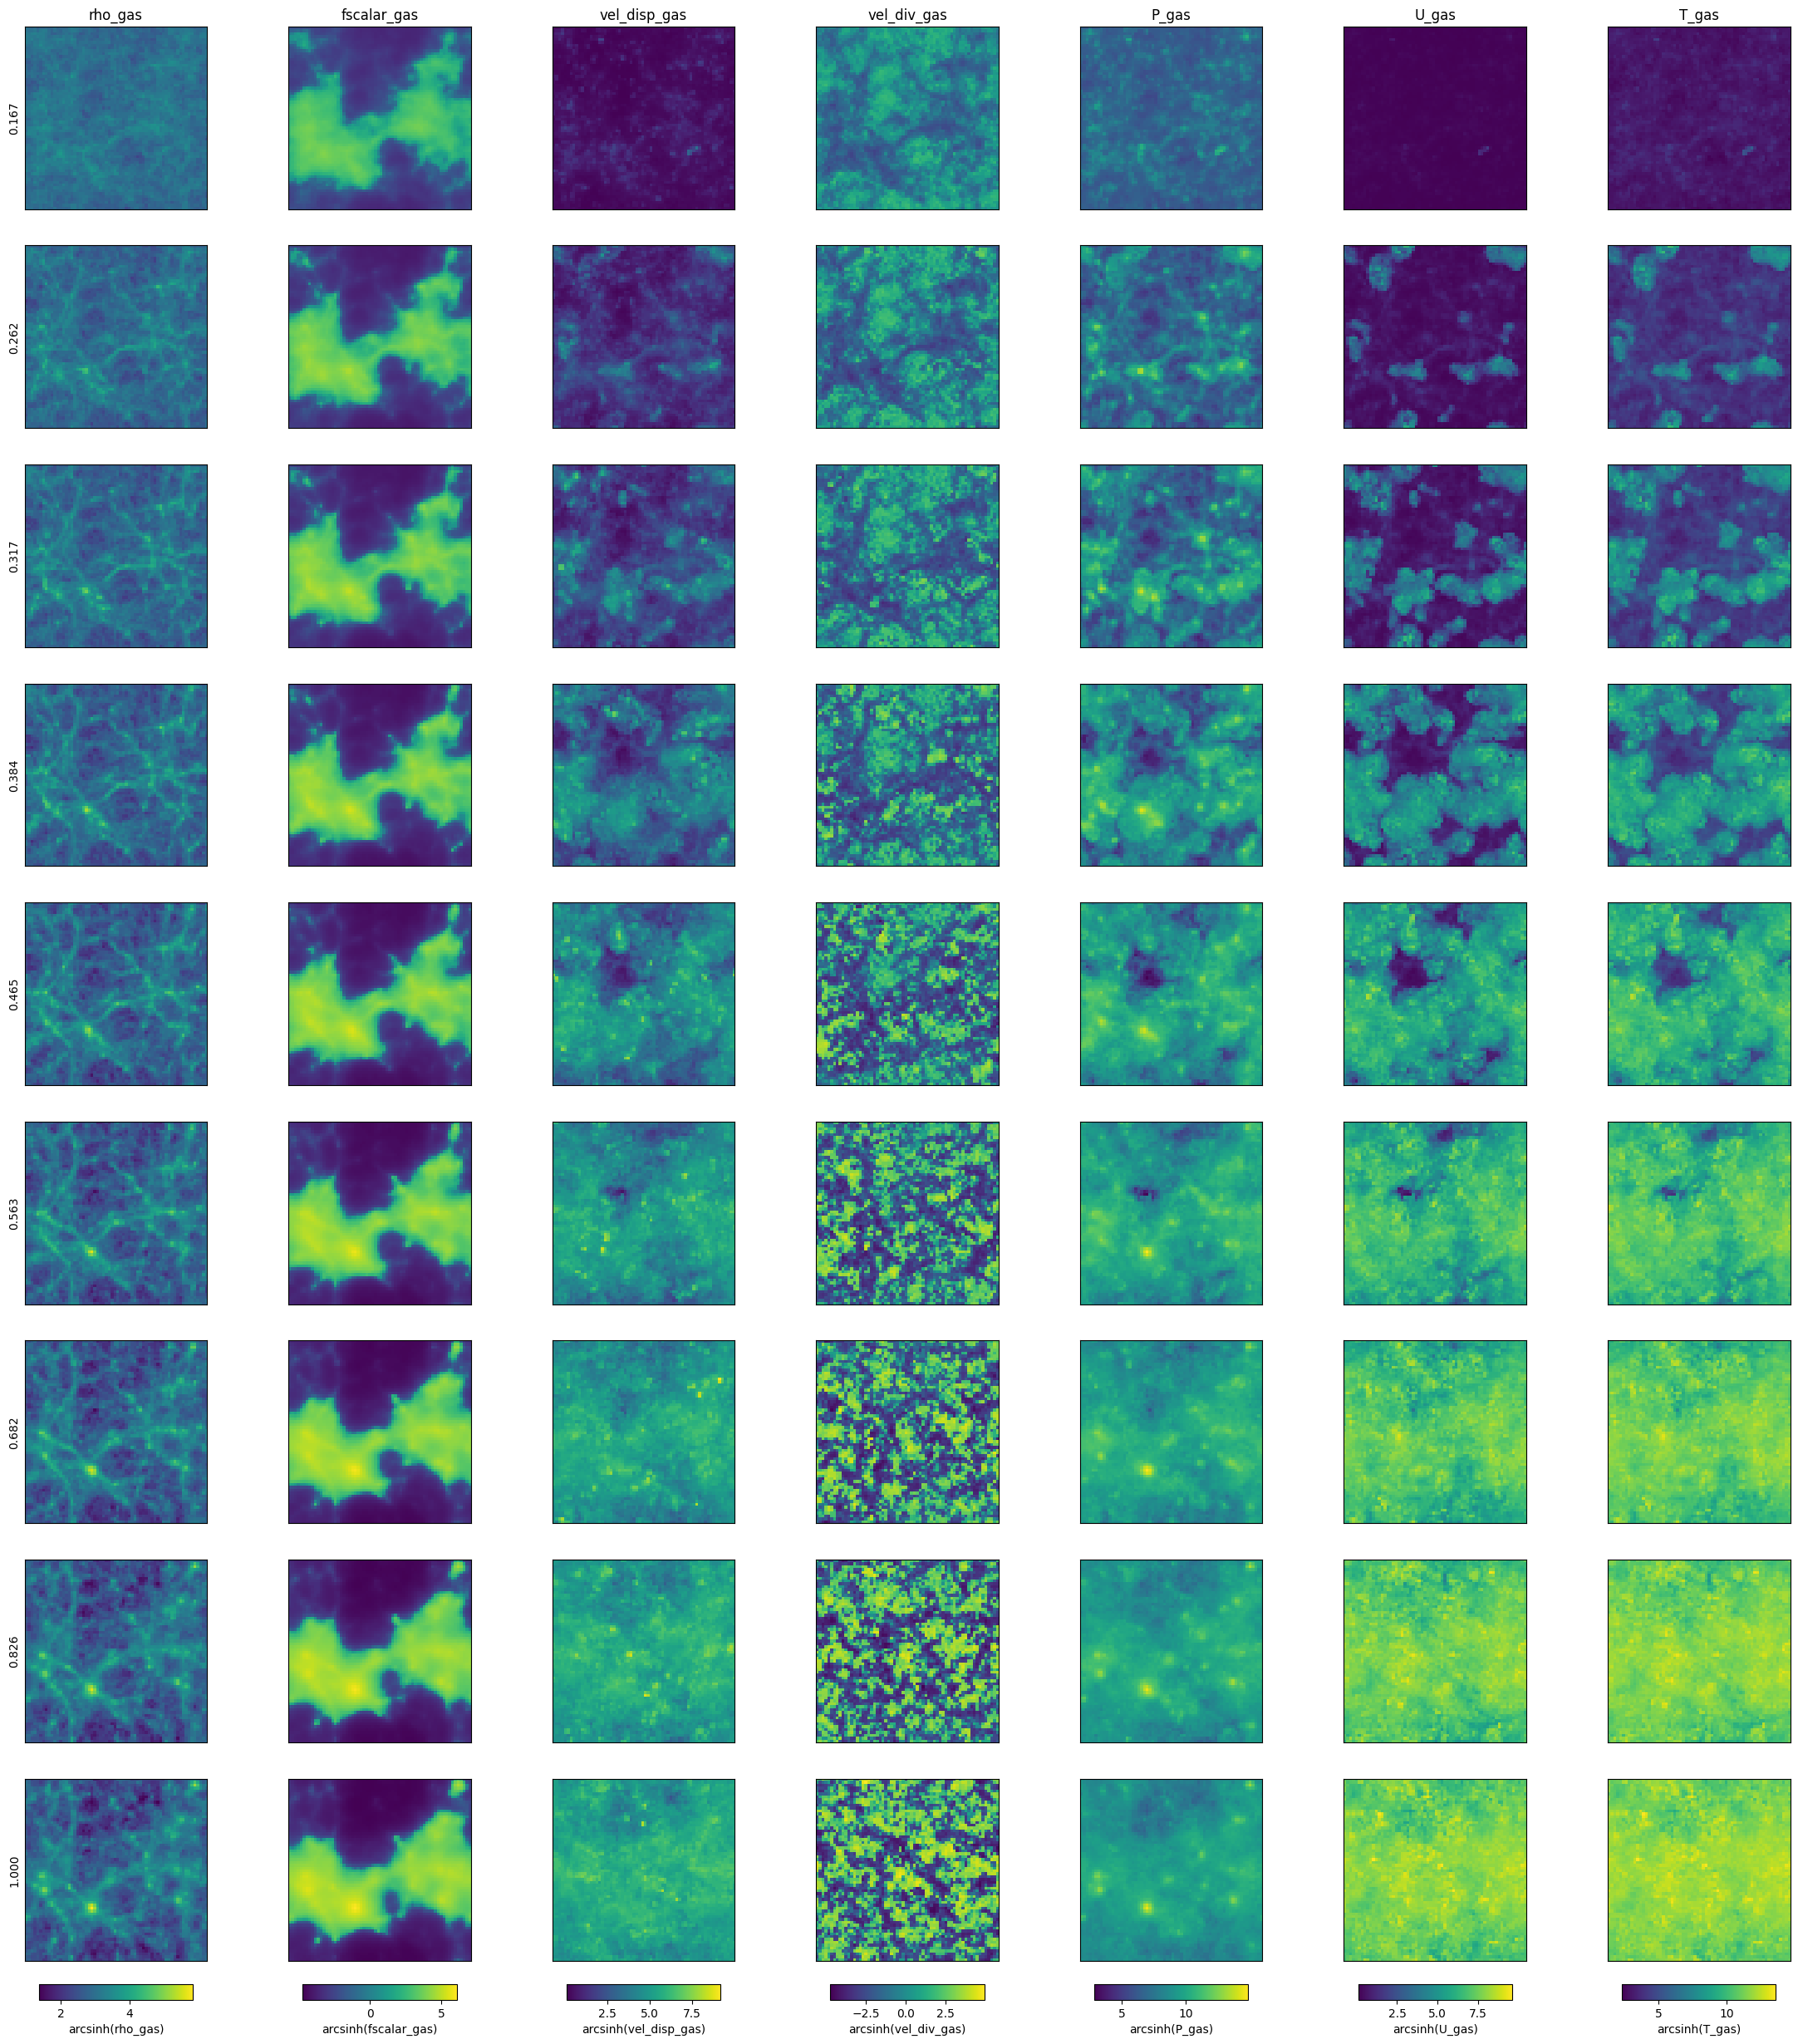

In [10]:
scales, particle_features, field_features = camels.preprocess_snapshots(train_dict)
plotting.plot_gas_features(scales, field_features)

# Network selection

In [11]:
from sklearn.preprocessing import StandardScaler

class TimeIndependentScaler3D:
    """
    A wrapper around sklearn's StandardScaler that handles 3D arrays with
    dimensions (n_times, n_samples, n_features) by scaling each time step
    independently.
    
    For each time step t, standardization is applied across samples for each feature.
    """
    
    def __init__(self, with_mean=True, with_std=True):
        self.with_mean = with_mean
        self.with_std = with_std
        self.scalers = None
        self.n_times = None
        self.n_features = None
        self.is_jax = None
        
    def fit(self, X):
        """
        Fit separate scalers for each time step in the 3D data.
        
        Parameters:
        -----------
        X : array-like of shape (n_times, n_samples, n_features)
            The data to fit the scalers on.
        """
        self.is_jax = isinstance(X, jax.Array)
        self.n_times, _, self.n_features = X.shape
        
        # Create a separate scaler for each time step
        self.scalers = []
        
        for t in range(self.n_times):
            # Get data for current time step
            if self.is_jax:
                X_t = np.array(X[t])  # Convert to numpy for sklearn
            else:
                X_t = X[t]
                
            # Create and fit a scaler for this time step
            scaler = StandardScaler(with_mean=self.with_mean, with_std=self.with_std)
            scaler.fit(X_t)
            self.scalers.append(scaler)
            
        return self
    
    def transform(self, X):
        """
        Transform 3D data using the fitted scalers, one time step at a time.
        
        Parameters:
        -----------
        X : array-like of shape (n_times, n_samples, n_features)
            The data to transform.
            
        Returns:
        --------
        X_scaled : array of shape (n_times, n_samples, n_features)
            The transformed data.
        """
        if self.scalers is None:
            raise ValueError("This TimeIndependentScaler3D instance is not fitted yet. "
                             "Call 'fit' before using this estimator.")
                             
        is_jax_input = isinstance(X, jax.Array)
        n_times, n_samples, n_features = X.shape
        
        if n_times != self.n_times:
            raise ValueError(f"Expected {self.n_times} time steps, got {n_times}")
        
        # Prepare output array
        if is_jax_input:
            X_transformed = np.zeros((n_times, n_samples, n_features))
        else:
            X_transformed = np.zeros_like(X)
        
        # Transform each time step separately
        for t in range(n_times):
            if is_jax_input:
                X_t = np.array(X[t])  # Convert to numpy for sklearn
            else:
                X_t = X[t]
                
            X_transformed[t] = self.scalers[t].transform(X_t)
        
        # Convert back to JAX array if input was JAX
        if is_jax_input:
            X_transformed = jnp.array(X_transformed)
            
        return X_transformed
    
    def fit_transform(self, X):
        """
        Fit the scalers and transform the data in one step.
        
        Parameters:
        -----------
        X : array-like of shape (n_times, n_samples, n_features)
            The data to fit and transform.
            
        Returns:
        --------
        X_scaled : array of shape (n_times, n_samples, n_features)
            The transformed data.
        """
        return self.fit(X).transform(X)
    
    def inverse_transform(self, X):
        """
        Inverse transform 3D scaled data back to the original representation.
        
        Parameters:
        -----------
        X : array-like of shape (n_times, n_samples, n_features)
            The scaled data to inverse transform.
            
        Returns:
        --------
        X_orig : array of shape (n_times, n_samples, n_features)
            The inverse transformed data.
        """
        if self.scalers is None:
            raise ValueError("This TimeIndependentScaler3D instance is not fitted yet. "
                             "Call 'fit' before using this estimator.")
                             
        is_jax_input = isinstance(X, jax.Array)
        n_times, n_samples, n_features = X.shape
        
        if n_times != self.n_times:
            raise ValueError(f"Expected {self.n_times} time steps, got {n_times}")
        
        # Prepare output array
        if is_jax_input:
            X_inv = np.zeros((n_times, n_samples, n_features))
        else:
            X_inv = np.zeros_like(X)
        
        # Inverse transform each time step separately
        for t in range(n_times):
            if is_jax_input:
                X_t = np.array(X[t])  # Convert to numpy for sklearn
            else:
                X_t = X[t]
                
            X_inv[t] = self.scalers[t].inverse_transform(X_t)
        
        # Convert back to JAX array if input was JAX
        if is_jax_input:
            X_inv = jnp.array(X_inv)
            
        return X_inv

In [12]:
def train_mlp(x_labels, y_labels, eps=1e-8, include_scale=True):
    X, _, Y, _ = data.get_offline_regression_data(
        train_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False, include_scale=include_scale
    )
    X_vali, _, Y_vali, _ = data.get_offline_regression_data(
        test_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False, include_scale=include_scale
    )

    # scaler = StandardScaler3D().fit(Y)
    # scaler = TimeIndependentScaler3D().fit(Y)
    # Y = scaler.transform(Y)
    # Y_vali = scaler.transform(Y_vali)
    # print("with standard scaler")

    model = MLP(
        X.shape[-1], 
        Y.shape[-1], 
        64, 
        4,
        nnx.Rngs(0),
        0.0,
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )

    pred = model(X)
    pred_vali = model(X_vali)

    with jax.default_device(jax.devices("cpu")[0]):
        plot_preds(pred, Y, pred_vali, Y_vali)
    
        # pred = scaler.inverse_transform(pred)
        # pred_vali = scaler.inverse_transform(pred_vali)

        i = -1
        P_pred = normalized_paint(train_dict["gas_poss"][i], jnp.squeeze(10**pred[i]) - eps)
        P_pred_vali = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) - eps)
        
        P_camels = normalized_paint(train_dict["gas_poss"][i], train_dict["gas_Ps"][i])
        P_camels_vali = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])
        
        plot_comparison(P_camels, P_pred, pred_label="MLP", suptitle="training set")
        plot_comparison(P_camels_vali, P_pred_vali, pred_label="MLP", suptitle="validation set")
    
    return model

# def train_hybrid(x_labels, y_labels):
#     X_particle, X_field, Y = get_data(train_dict, y_labels=y_labels)
#     X_particle_vali, X_field_vali, Y_vali = get_data(test_dict, y_labels=y_labels)
    
#     mlp = MLP(
#         d_in=X_particle.shape[-1], 
#         d_out=8, 
#         d_hidden=64, 
#         n_hidden=4, 
#         rngs=nnx.Rngs(0)
#     )
    
#     cnn = CNN(
#         d_in=X_field.shape[-1], 
#         d_out=8,
#         d_hidden=16,
#         n_hidden=1,
#         kernel_size=(3, 3, 3),
#         strides=1,
#         rngs=nnx.Rngs(0)
#     )
    
#     hybrid = HybridNet(
#         mlp,
#         cnn,
#         d_out=Y.shape[-1],
#         rngs=nnx.Rngs(0),
#         batch_axis=False,
#     )    
    # return hybrid


def train_gnn(x_labels, y_labels):
    X, Y = graph.get_graphs_from_snapshots(
        train_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )
    
    X_vali, Y_vali = graph.get_graphs_from_snapshots(
        test_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )

    model = AttentionGNN(
        d_node=X[0].nodes.shape[-1],
        d_edge=X[0].edges.shape[-1],
        d_query=16,
        n_hidden=4,
        d_out=Y.shape[-1],
        rngs=nnx.Rngs(0),
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )

    pred = []
    for x in X:
        pred.append(model(x))
    pred = jnp.stack(pred, axis=0)
        
    pred_vali = []
    for x in X_vali:
        pred_vali.append(model(x))
    pred_vali = jnp.stack(pred_vali, axis=0)

    plot_preds(pred, Y, pred_vali, Y_vali)

    i = -1
    P_pred = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) - 1)
    P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])
    plot_comparison(P_camels, P_pred, pred_label="GNN", suptitle="validation set")
    
    return model


# training

In [13]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
# x_labels = ["rho", "fscalar"]
y_labels = ["P"]

# model = train_mlp(x_labels, y_labels)
# # model = train_gnn(x_labels, y_labels)

# model = train_mlp(x_labels, y_labels, include_scale=False)
# # model = train_gnn(x_labels, y_labels)

In [14]:
# X, _, Y, _ = data.get_offline_regression_data(
#     train_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False, include_scale=True
# )

# # print(X.shape)
# # print(Y.shape)

In [ ]:
model = train_mlp(x_labels, y_labels)

train=0.2018, vali=0.5054:  28%|██▊       | 852/3000 [00:11<00:21, 99.79it/s] 

In [ ]:
# model = train_mlp(x_labels, y_labels, include_scale=False)

In [ ]:
# model = train_mlp(x_labels, y_labels, include_scale=False)

In [ ]:
# see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_table_v1.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_table_illustris_cv1.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_table_v1_late_time.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_table_v2.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_table_v3_subset.jx")
checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_table_v3.jx")
checkpointer = ocp.StandardCheckpointer()
print(os.getcwd())

In [ ]:
_, params = nnx.split(model)
checkpointer.save(checkpoint_file, params, force=True)

In [ ]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# tests

In [ ]:
X, _, Y, _ = data.get_offline_regression_data(
    train_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False, include_scale=True
)

In [ ]:
X[0,:10,:]

In [ ]:
X, _, Y, _ = data.get_offline_regression_data(
    train_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False, include_scale=False
)

In [ ]:
X.shape

In [ ]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
# x_labels = ["rho", "fscalar"]
y_labels = ["P"]

X, _, Y, _ = data.get_offline_regression_data(
    train_dict, x_labels=x_labels, y_labels=y_labels, standardize_input=False, include_scale=True
)

print(X.shape)

In [ ]:
i = 0

cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

scale = scales[i]
gas_pos = gas_poss[i]
gas_vel = gas_vels[i]

N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
rho_gas = N_gas * cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)
gas_N = cic_read(N_gas, gas_pos)
gas_rho = cic_read(rho_gas, gas_pos)

X_online = data.get_hpm_inputs(
    scale,
    gas_pos,
    gas_vel,
    gas_rho,
    rho_gas,
    gas_N,
    mesh_shape,
    return_vel=True,
    # return_vel=False,
    return_field=False,
)

print(X_online.shape)

In [ ]:
for j in range(X.shape[-1]):
    print(jnp.allclose(X_online[:,j], X[i,:,j], rtol=1e-3, atol=1e-3))
    print(X_online[:,j])
    print(X[i,:,j], "\n")

In [ ]:
X_online[:,0]

In [ ]:
X[i,:,0]

In [ ]:
X